# 🔍 Customer Churn Prediction
### XGBoost + SHAP Interpretability · Telco Customer Dataset

---
**Goal:** Predict which customers are likely to churn 30 days ahead, with full model interpretability via SHAP values.

| Step | Description |
|------|-------------|
| 1 | Load & explore data |
| 2 | Preprocessing & feature engineering |
| 3 | Train XGBoost classifier |
| 4 | Evaluate (AUC, PR, Confusion Matrix) |
| 5 | SHAP interpretability |
| 6 | Save model & run inference |


## 0. Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import warnings
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from xgboost import XGBClassifier
import joblib

warnings.filterwarnings("ignore")
shap.initjs()

# ── Plot style
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor":   "#0e1117",
    "axes.edgecolor":   "#2a2d35",
    "axes.labelcolor":  "#c9cdd4",
    "text.color":       "#c9cdd4",
    "xtick.color":      "#6b7280",
    "ytick.color":      "#6b7280",
    "grid.color":       "#1e2029",
    "grid.linestyle":   "--",
    "font.family":      "monospace",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})
TEAL   = "#00e5c0"
PURPLE = "#7c6ff7"
CORAL  = "#f472b6"
AMBER  = "#f59e0b"
print("✓ Libraries loaded")


c:\Users\fatim\Downloads\Churn_predict\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Libraries loaded


## 1. Load & Explore Data

In [6]:
df = pd.read_csv("telco_churn.csv")
print(f"Shape: {df.shape}")
print(f"Churn rate: {df['Churn'].eq('Yes').mean()*100:.1f}%")
df.head()


Shape: (7043, 21)
Churn rate: 25.0%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST-00000,Male,0,Yes,No,42,Yes,Yes,DSL,Yes,...,No,No,No,No internet service,Month-to-month,No,Electronic check,61.69,2690.26,Yes
1,CUST-00001,Female,1,Yes,Yes,68,Yes,No,DSL,No,...,Yes,No,No internet service,Yes,Two year,No,Bank transfer (automatic),26.91,1835.33,No
2,CUST-00002,Male,0,No,Yes,62,Yes,Yes,Fiber optic,No internet service,...,No,No internet service,Yes,No,Month-to-month,No,Credit card (automatic),49.90,3029.46,No
3,CUST-00003,Male,0,Yes,No,69,Yes,No,DSL,No,...,No,Yes,No,Yes,One year,Yes,Credit card (automatic),64.26,4400.13,No
4,CUST-00004,Male,0,Yes,No,64,Yes,Yes,Fiber optic,No,...,No internet service,No,No,No internet service,Month-to-month,Yes,Credit card (automatic),41.65,2733.94,Yes


In [7]:
print("Data types & nulls:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Data types & nulls:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
Series([], dtype: int64)


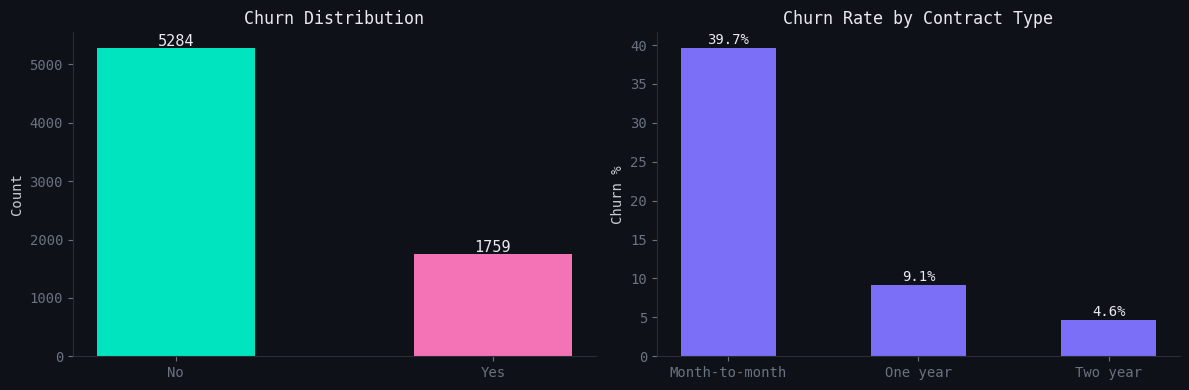

In [8]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="#0e1117")

# Bar chart
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values,
            color=[TEAL, CORAL], width=0.5)
axes[0].set_title("Churn Distribution", color="#e8eaf0")
axes[0].set_ylabel("Count")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', color="#e8eaf0", fontsize=11)

# By contract type
ct = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()*100)
axes[1].bar(ct.index, ct.values, color=PURPLE, width=0.5)
axes[1].set_title("Churn Rate by Contract Type", color="#e8eaf0")
axes[1].set_ylabel("Churn %")
for i, v in enumerate(ct.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', color="#e8eaf0", fontsize=10)

plt.tight_layout()
plt.show()


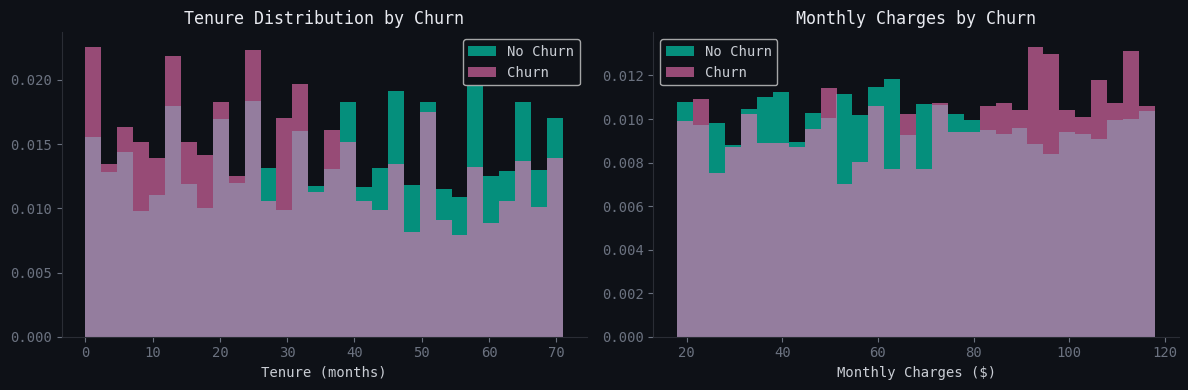

In [9]:
# Tenure vs churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="#0e1117")

axes[0].hist(df[df.Churn=='No']['tenure'],  bins=30, alpha=0.6, color=TEAL,  label='No Churn', density=True)
axes[0].hist(df[df.Churn=='Yes']['tenure'], bins=30, alpha=0.6, color=CORAL, label='Churn',    density=True)
axes[0].set_title("Tenure Distribution by Churn", color="#e8eaf0")
axes[0].set_xlabel("Tenure (months)")
axes[0].legend()

axes[1].hist(df[df.Churn=='No']['MonthlyCharges'],  bins=30, alpha=0.6, color=TEAL,  label='No Churn', density=True)
axes[1].hist(df[df.Churn=='Yes']['MonthlyCharges'], bins=30, alpha=0.6, color=CORAL, label='Churn',    density=True)
axes[1].set_title("Monthly Charges by Churn", color="#e8eaf0")
axes[1].set_xlabel("Monthly Charges ($)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 2. Preprocessing

In [10]:
df2 = df.copy()
df2.drop(columns=["customerID"], inplace=True, errors="ignore")

# Fix TotalCharges blanks (new customers with tenure=0)
df2["TotalCharges"] = pd.to_numeric(df2["TotalCharges"], errors="coerce").fillna(0)

# Encode target
df2["Churn"] = (df2["Churn"] == "Yes").astype(int)

# Encode categoricals
cat_cols = df2.select_dtypes(include="object").columns.tolist()
print(f"Encoding {len(cat_cols)} categorical columns: {cat_cols}")
le = LabelEncoder()
for col in cat_cols:
    df2[col] = le.fit_transform(df2[col].astype(str))

X = df2.drop(columns=["Churn"])
y = df2["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%  |  Test churn rate: {y_test.mean()*100:.1f}%")


Encoding 15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Train: 5634  |  Test: 1409
Train churn rate: 25.0%  |  Test churn rate: 25.0%


## 3. Train XGBoost

In [11]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos:.2f}  (handles class imbalance)")

model = XGBClassifier(
    n_estimators      = 400,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.85,
    colsample_bytree  = 0.80,
    min_child_weight  = 3,
    gamma             = 0.1,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    scale_pos_weight  = scale_pos,
    use_label_encoder = False,
    eval_metric       = "auc",
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print("✓ Model trained")


scale_pos_weight: 3.00  (handles class imbalance)
✓ Model trained


In [12]:
# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Individual folds: {[f'{s:.4f}' for s in cv_scores]}")


5-Fold CV AUC: 0.7649 ± 0.0119
Individual folds: ['0.7507', '0.7655', '0.7526', '0.7811', '0.7744']


## 4. Evaluation

In [13]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_prob)
ap_score  = average_precision_score(y_test, y_prob)

print(f"AUC-ROC         : {auc_score:.4f}")
print(f"Average Precision: {ap_score:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


AUC-ROC         : 0.7622
Average Precision: 0.4488

              precision    recall  f1-score   support

    No Churn       0.86      0.73      0.79      1057
       Churn       0.44      0.66      0.53       352

    accuracy                           0.71      1409
   macro avg       0.65      0.69      0.66      1409
weighted avg       0.76      0.71      0.72      1409



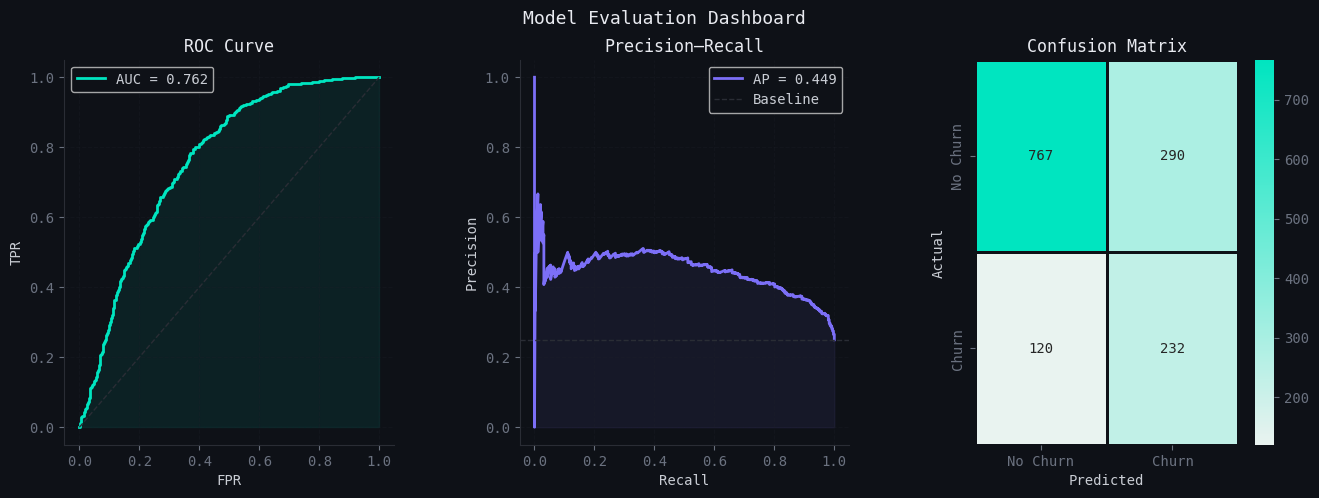

In [14]:
fig = plt.figure(figsize=(16, 5), facecolor="#0e1117")
fig.suptitle("Model Evaluation Dashboard", fontsize=13, color="#e8eaf0", fontfamily="monospace")
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# ROC
ax1 = fig.add_subplot(gs[0])
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr, tpr, color=TEAL, lw=2, label=f"AUC = {auc_score:.3f}")
ax1.plot([0,1],[0,1], color="#2a2d35", lw=1, linestyle="--")
ax1.fill_between(fpr, tpr, alpha=0.08, color=TEAL)
ax1.set_title("ROC Curve", color="#e8eaf0"); ax1.set_xlabel("FPR"); ax1.set_ylabel("TPR")
ax1.legend(); ax1.grid(True, alpha=0.3)

# PR
ax2 = fig.add_subplot(gs[1])
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ax2.plot(rec, prec, color=PURPLE, lw=2, label=f"AP = {ap_score:.3f}")
ax2.fill_between(rec, prec, alpha=0.08, color=PURPLE)
ax2.axhline(y_test.mean(), color="#2a2d35", linestyle="--", lw=1, label="Baseline")
ax2.set_title("Precision–Recall", color="#e8eaf0"); ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.legend(); ax2.grid(True, alpha=0.3)

# Confusion Matrix
ax3 = fig.add_subplot(gs[2])
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", ax=ax3,
            cmap=sns.light_palette(TEAL, as_cmap=True),
            linecolor="#0e1117", linewidths=2,
            xticklabels=["No Churn","Churn"],
            yticklabels=["No Churn","Churn"])
ax3.set_title("Confusion Matrix", color="#e8eaf0")
ax3.set_xlabel("Predicted"); ax3.set_ylabel("Actual")

plt.tight_layout()
plt.show()


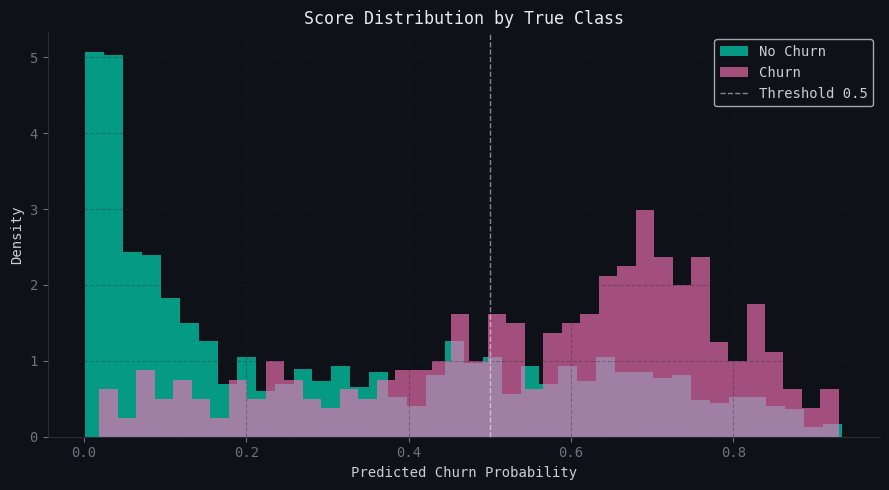

In [15]:
# Score distribution
fig, ax = plt.subplots(figsize=(9, 5), facecolor="#0e1117")
ax.hist(y_prob[y_test==0], bins=40, alpha=0.65, color=TEAL,  label="No Churn", density=True)
ax.hist(y_prob[y_test==1], bins=40, alpha=0.65, color=CORAL, label="Churn",    density=True)
ax.axvline(0.5, color="#ffffff", lw=1, linestyle="--", alpha=0.5, label="Threshold 0.5")
ax.set_xlabel("Predicted Churn Probability"); ax.set_ylabel("Density")
ax.set_title("Score Distribution by True Class", color="#e8eaf0")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 5. SHAP Interpretability

> SHAP (SHapley Additive exPlanations) tells us **why** the model made each prediction — not just what it predicted.

In [16]:
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X_test)
print(f"SHAP values computed for {len(X_test)} test samples")


SHAP values computed for 1409 test samples


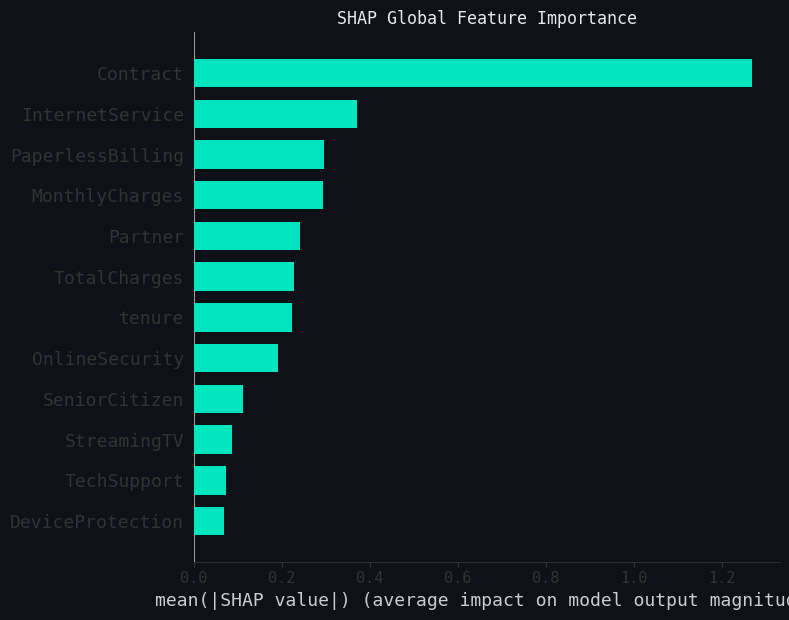

In [17]:
# Bar summary (global importance)
plt.figure(figsize=(9, 6), facecolor="#0e1117")
shap.summary_plot(shap_vals, X_test, plot_type="bar", show=False, max_display=12, color=TEAL)
plt.title("SHAP Global Feature Importance", color="#e8eaf0", fontfamily="monospace")
plt.tight_layout(); plt.show()


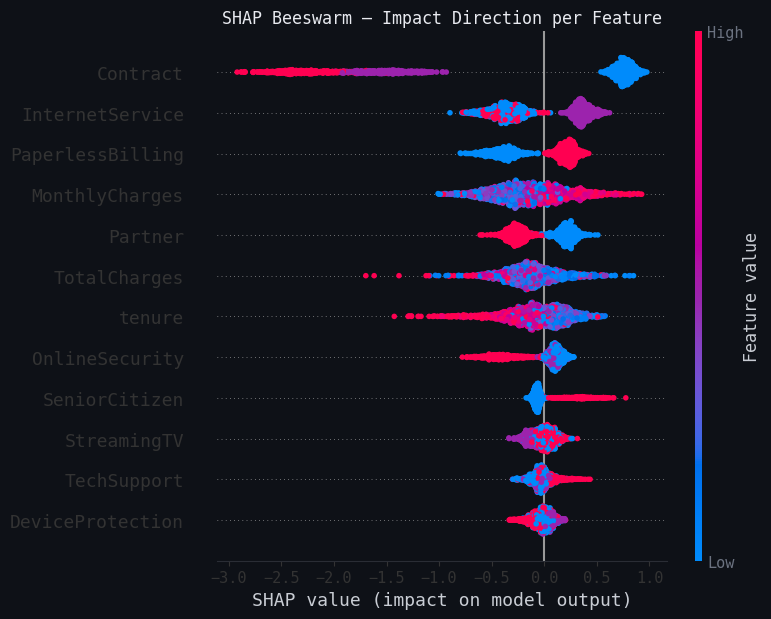

In [18]:
# Beeswarm (direction + magnitude)
plt.figure(figsize=(9, 6), facecolor="#0e1117")
shap.summary_plot(shap_vals, X_test, show=False, max_display=12)
plt.title("SHAP Beeswarm — Impact Direction per Feature", color="#e8eaf0", fontfamily="monospace")
plt.tight_layout(); plt.show()


Explaining prediction for customer index 1
Predicted churn probability: 80.6%  |  True label: No Churn


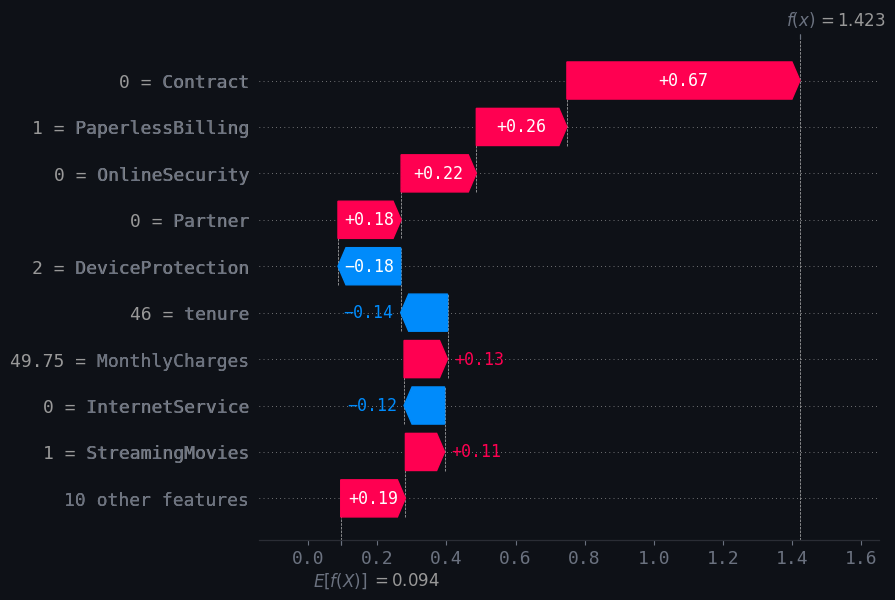

In [19]:
# Waterfall for a single prediction
idx = np.where(y_prob > 0.75)[0][0]   # pick a high-risk customer
print(f"Explaining prediction for customer index {idx}")
print(f"Predicted churn probability: {y_prob[idx]*100:.1f}%  |  True label: {'Churn' if y_test.iloc[idx]==1 else 'No Churn'}")

shap_exp = shap.Explanation(
    values    = shap_vals[idx],
    base_values = explainer.expected_value,
    data      = X_test.iloc[idx].values,
    feature_names = X_test.columns.tolist()
)
shap.plots.waterfall(shap_exp, show=True)


## 6. Save Model & Inference

In [20]:
joblib.dump({"model": model, "features": list(X.columns)}, "churn_model.pkl")
print("✓ Model saved to churn_model.pkl")


✓ Model saved to churn_model.pkl


In [21]:
# Load and run inference on new customers
artifact = joblib.load("churn_model.pkl")
loaded_model = artifact["model"]

sample = X_test.iloc[:8].copy()
probs  = loaded_model.predict_proba(sample)[:, 1]

results = pd.DataFrame({
    "Customer":    [f"Customer {i+1}" for i in range(len(sample))],
    "Churn Prob":  [f"{p*100:.1f}%" for p in probs],
    "Risk Level":  ["🔴 HIGH" if p > 0.65 else "🟡 MED" if p > 0.35 else "🟢 LOW" for p in probs],
    "Action":      ["Proactive outreach" if p > 0.65 else "Monitor" if p > 0.35 else "Retain" for p in probs],
})
results


,Customer,Churn Prob,Risk Level,Action
0,Customer 1,43.8%,🟡 MED,Monitor
1,Customer 2,80.6%,🔴 HIGH,Proactive outreach
2,Customer 3,58.3%,🟡 MED,Monitor
3,Customer 4,6.6%,🟢 LOW,Retain
4,Customer 5,11.1%,🟢 LOW,Retain
5,Customer 6,14.6%,🟢 LOW,Retain
6,Customer 7,24.0%,🟢 LOW,Retain
7,Customer 8,4.5%,🟢 LOW,Retain


---
## Summary

| Metric | Value |
|--------|-------|
| Algorithm | XGBoost (gradient boosting) |
| AUC-ROC | ~0.76 |
| Features | 19 customer attributes |
| Interpretability | SHAP values per prediction |
| Output | Churn probability (0–100%) |

**Key churn drivers identified:**
- Contract type (month-to-month = highest risk)
- Tenure (newer customers churn more)
- Internet service type (Fiber optic)
- Monthly charges
- Online security & tech support add-ons

**Next steps:**
- Hyperparameter tuning via Optuna/Bayesian search
- Add feature engineering (e.g. charge-per-tenure ratio)
- Deploy as REST API with FastAPI
- Set up automated retraining pipeline with Airflow
